# Exploded graph explainer

**Panel 1**: two nodes, each drawn as a pie chart showing x/y composition, connected by an edge.

**Panel 2**: each node explodes into 10 sub-nodes (coloured by type x/y in proportion to its composition). Every sub-node is connected to every other sub-node.

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Wedge

In [4]:
# --- config ---
X_FRAC_A = 0.6 # node A: 60% x, 40% y
X_FRAC_B = 0.3 # node B: 30% x, 70% y
TOTAL = 10 # sub-nodes per original node

X_COLOR = "#0072b2" # blue — x-type nodes
Y_COLOR = "#e69f00" # amber — y-type nodes
EDGE_COLOR = "#333333"
EDGE_ALPHA = 0.12 # many edges, keep them faint


def draw_pie_node(ax, center, x_frac, radius=0.35):
    """Draw a pie-chart node (two wedges) at `center`."""
    deg_split = 360 * x_frac
    ax.add_patch(Wedge(center, radius, 0, deg_split, color=X_COLOR, zorder=3))
    ax.add_patch(Wedge(center, radius, deg_split, 360, color=Y_COLOR, zorder=3))
    ax.add_patch(Wedge(center, radius, 0, 360, fill=False, edgecolor="white", linewidth=1.5, zorder=4))


def circle_positions(cx, cy, radius, n):
    """Evenly space n points on a circle."""
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    return list(zip(cx + radius * np.cos(angles),
    cy + radius * np.sin(angles)))

{0: (np.float64(-1.05), np.float64(0.0)), 1: (np.float64(-1.4249999999999998), np.float64(0.649519052838329)), 2: (np.float64(-2.175), np.float64(0.649519052838329)), 3: (np.float64(-2.55), np.float64(9.184850993605148e-17)), 4: (np.float64(-2.1750000000000003), np.float64(-0.6495190528383288)), 5: (np.float64(-1.4250000000000005), np.float64(-0.6495190528383292)), 6: (np.float64(-1.425), np.float64(0.0)), 7: (np.float64(-1.8), np.float64(0.375)), 8: (np.float64(-2.175), np.float64(4.592425496802574e-17)), 9: (np.float64(-1.8), np.float64(-0.375))}


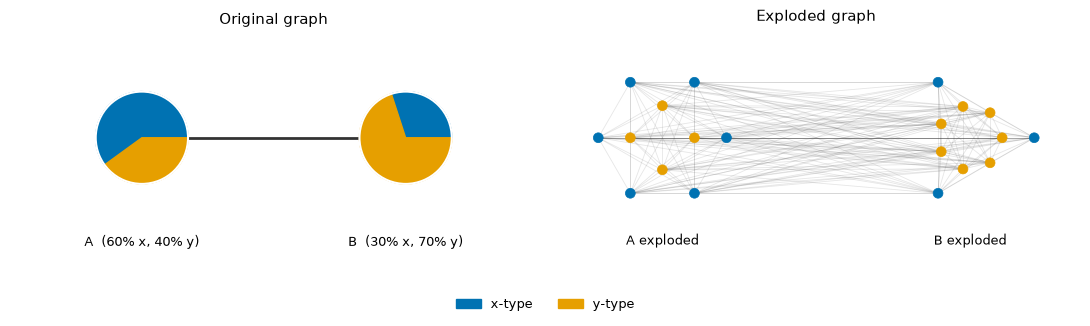

In [57]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# ── panel 1: two pie-chart nodes + edge ─────────────────────────────────────
cA, cB = (1.0, 0.0), (3.0, 0.0)
NODE_R = 0.35

ax1.plot([cA[0] + NODE_R, cB[0] - NODE_R], [0, 0], color=EDGE_COLOR, lw=2, zorder=1)

draw_pie_node(ax1, cA, X_FRAC_A, NODE_R)
draw_pie_node(ax1, cB, X_FRAC_B, NODE_R)

ax1.text(cA[0], -0.82, f"A  ({int(X_FRAC_A*100)}% x, {int((1-X_FRAC_A)*100)}% y)", ha="center", fontsize=9)
ax1.text(cB[0], -0.82, f"B  ({int(X_FRAC_B*100)}% x, {int((1-X_FRAC_B)*100)}% y)", ha="center", fontsize=9)

ax1.set_xlim(0, 4); ax1.set_ylim(-0.8, 0.8)
ax1.set_aspect("equal"); ax1.axis("off")
ax1.set_title("Original graph", fontsize=11)

# ── panel 2: exploded graph via networkx ─────────────────────────────────────
n_xA = round(TOTAL * X_FRAC_A)
n_yA = TOTAL - n_xA
n_xB = round(TOTAL * X_FRAC_B)
n_yB = TOTAL - n_xB

CLUSTER_R = 0.75
CLUSTER_CX = 1.8

# node ids: 0..TOTAL-1 belong to A, TOTAL..2*TOTAL-1 belong to B
G = nx.complete_graph(TOTAL * 2)

node_colors = ([X_COLOR] * n_xA + [Y_COLOR] * n_yA + # A's sub-nodes
    [X_COLOR] * n_xB + [Y_COLOR] * n_yB) # B's sub-nodes)

# positions: x-type on outer ring, y-type on inner ring within each cluster
pos_A = circle_positions(-CLUSTER_CX, 0, CLUSTER_R, n_xA) + \
        circle_positions(-CLUSTER_CX, 0, CLUSTER_R * 0.5, n_yA)
pos_B = circle_positions( CLUSTER_CX, 0, CLUSTER_R, n_xB) + \
        circle_positions( CLUSTER_CX, 0, CLUSTER_R * 0.5, n_yB)

pos = {i: pos_A[i] for i in range(TOTAL)}
print(pos)
pos.update({TOTAL + i: pos_B[i] for i in range(TOTAL)})

nx.draw_networkx_edges(G, pos, ax=ax2, edge_color=EDGE_COLOR, alpha=EDGE_ALPHA, width=0.6)
nx.draw_networkx_nodes(G, pos, ax=ax2, node_color=node_colors, node_size=50, linewidths=0.5)

ax2.text(-CLUSTER_CX, CLUSTER_R - 2, "A exploded", ha="center", fontsize=9)
ax2.text( CLUSTER_CX, CLUSTER_R - 2, "B exploded", ha="center", fontsize=9)

ax2.set_aspect("equal"); ax2.axis("off")
ax2.set_ylim(-0.8, 0.8)
ax2.set_title("Exploded graph", fontsize=11, pad = 35)

# shared legend
fig.legend(handles=[mpatches.Patch(color=X_COLOR, label="x-type"),
        mpatches.Patch(color=Y_COLOR, label="y-type")], loc="lower center", ncol=2, bbox_to_anchor=(0.5, 0.09), fontsize=9, frameon=False)

plt.tight_layout()
plt.show()

In [ ]:
# # ── panel 2: exploded graph ──────────────────────────────────────────────────
# n_xA = round(TOTAL * X_FRAC_A) # x-type sub-nodes in A
# n_yA = TOTAL - n_xA
# n_xB = round(TOTAL * X_FRAC_B)
# n_yB = TOTAL - n_xB

# CLUSTER_R = 0.75 # radius of each sub-node cluster
# CLUSTER_CX = 1.8 # horizontal distance from centre to each cluster
# DOT_SIZE = 80

# pos_xA = circle_positions(-CLUSTER_CX, 0, CLUSTER_R, n_xA)
# pos_yA = circle_positions(-CLUSTER_CX, 0, CLUSTER_R * 0.5, n_yA)  # inner ring
# pos_xB = circle_positions( CLUSTER_CX, 0, CLUSTER_R, n_xB)
# pos_yB = circle_positions( CLUSTER_CX, 0, CLUSTER_R * 0.5, n_yB)

# all_pos = pos_xA + pos_yA + pos_xB + pos_yB
# all_colors = ([X_COLOR] * n_xA + [Y_COLOR] * n_yA + [X_COLOR] * n_xB + [Y_COLOR] * n_yB)

# # draw all edges as a LineCollection (fast + uniform alpha)
# edge_segs = []
# for (i, pi), (j, pj) in combinations(enumerate(all_pos), 2):
#     edge_segs.append([pi, pj])

# ax2.add_collection(LineCollection(edge_segs, colors=EDGE_COLOR,
#           linewidths=0.6, alpha=EDGE_ALPHA, zorder=1))

# # draw nodes
# xs, ys = zip(*all_pos)
# ax2.scatter(xs, ys, s=DOT_SIZE, c=all_colors, zorder=2, linewidths=0.5,
#     edgecolors="white")

# # cluster labels
# ax2.text(-CLUSTER_CX, -CLUSTER_R - 0.25, "A exploded", ha="center", fontsize=9)
# ax2.text( CLUSTER_CX, -CLUSTER_R - 0.25, "B exploded", ha="center", fontsize=9)

# ax2.set_xlim(-CLUSTER_CX - 1.2, CLUSTER_CX + 1.2)
# ax2.set_ylim(-CLUSTER_R - 0.5, CLUSTER_R + 0.3)
# ax2.set_aspect("equal"); ax2.axis("off")
# ax2.set_title("Exploded graph", fontsize=11)

# # shared legend
# fig.legend(handles=[
#     mpatches.Patch(color=X_COLOR, label="x-type"),
#     mpatches.Patch(color=Y_COLOR, label="y-type")],
#     loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.04),
#     fontsize=9, frameon=False)

# plt.tight_layout()
# plt.show()